In [1]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "sales": [100, 200, 150, 300, 5000, 700, 3000, 1500, 400, 600] # 5000 is an outlier
})
print(df.describe())

             sales
count    10.000000
mean   1195.000000
std    1603.546417
min     100.000000
25%     225.000000
50%     500.000000
75%    1300.000000
max    5000.000000


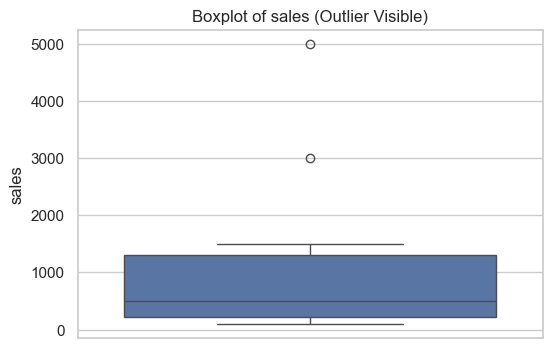

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

plt.figure(figsize=(6,4))
sns.boxplot(y=df["sales"])
plt.title("Boxplot of sales (Outlier Visible)")
plt.show()

In [5]:
# Clipping
df['sales_clipped'] = df['sales'].clip(upper = 1000)
print(df)

   sales  sales_clipped
0    100            100
1    200            200
2    150            150
3    300            300
4   5000           1000
5    700            700
6   3000           1000
7   1500           1000
8    400            400
9    600            600


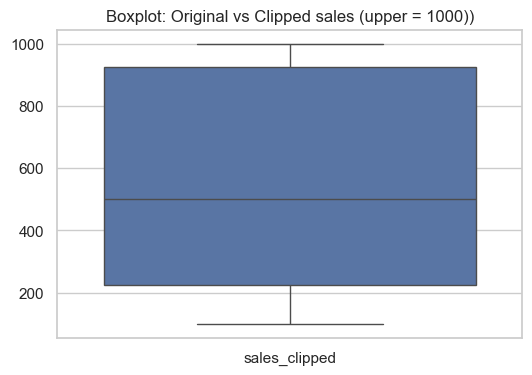

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

plt.figure(figsize=(6,4))
sns.boxplot(data=df[[ "sales_clipped" ]])
plt.title("Boxplot: Original vs Clipped sales (upper = 1000))")
plt.show()

In [7]:
from scipy.stats.mstats import winsorize
# Winsorization top 20% capped
df['sales_winsor'] = winsorize(df['sales'], limits=[0, 0.2])
print(df)

   sales  sales_clipped  sales_winsor
0    100            100           100
1    200            200           200
2    150            150           150
3    300            300           300
4   5000           1000          1500
5    700            700           700
6   3000           1000          1500
7   1500           1000          1500
8    400            400           400
9    600            600           600


In [8]:
# removal (drop outlier > 1000 )
df['sales_removed'] = df['sales'].where(df['sales'] <= 1000, np.nan)
print(df)

   sales  sales_clipped  sales_winsor  sales_removed
0    100            100           100          100.0
1    200            200           200          200.0
2    150            150           150          150.0
3    300            300           300          300.0
4   5000           1000          1500            NaN
5    700            700           700          700.0
6   3000           1000          1500            NaN
7   1500           1000          1500            NaN
8    400            400           400          400.0
9    600            600           600          600.0


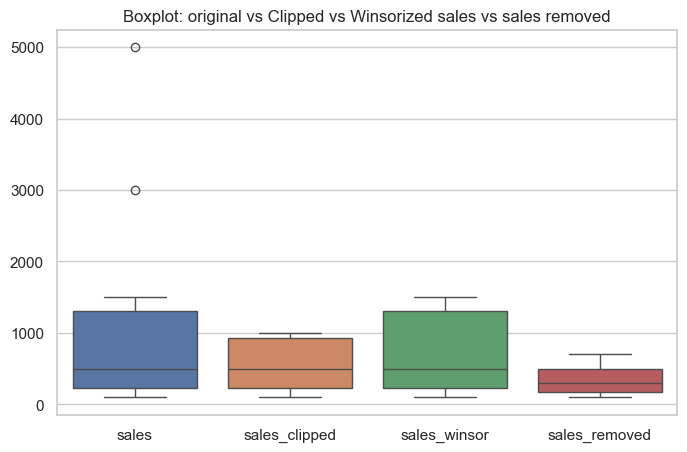

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")
plt.figure(figsize=(8,5))
sns.boxplot(data=df[["sales", "sales_clipped", "sales_winsor", "sales_removed"]])
plt.title("Boxplot: original vs Clipped vs Winsorized sales vs sales removed")
plt.show()